# Complete Task

--- Task 1: Downloading and Analyzing Dataset ---
Using Colab cache for faster access to the 'sentiment-analysis-for-mental-health' dataset.
Path to dataset files: /kaggle/input/sentiment-analysis-for-mental-health

Total Number of Sentiment Classes: 7

Class Distribution & Imbalance Analysis:
 - Class 'Normal': 16343 samples (31.02%)
 - Class 'Depression': 15404 samples (29.24%)
 - Class 'Suicidal': 10652 samples (20.22%)
 - Class 'Anxiety': 3841 samples (7.29%)
 - Class 'Bipolar': 2777 samples (5.27%)
 - Class 'Stress': 2587 samples (4.91%)
 - Class 'Personality disorder': 1077 samples (2.04%)

Sentence Length Statistics:
 - Average Sentence Length: 113.16 words
 - Maximum Sentence Length: 6300 words
 - 95th Percentile Length (Recommended Max Len): 395 words



/tmp/ipykernel_33478/1566386246.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='status', order=class_counts.index, palette='viridis')


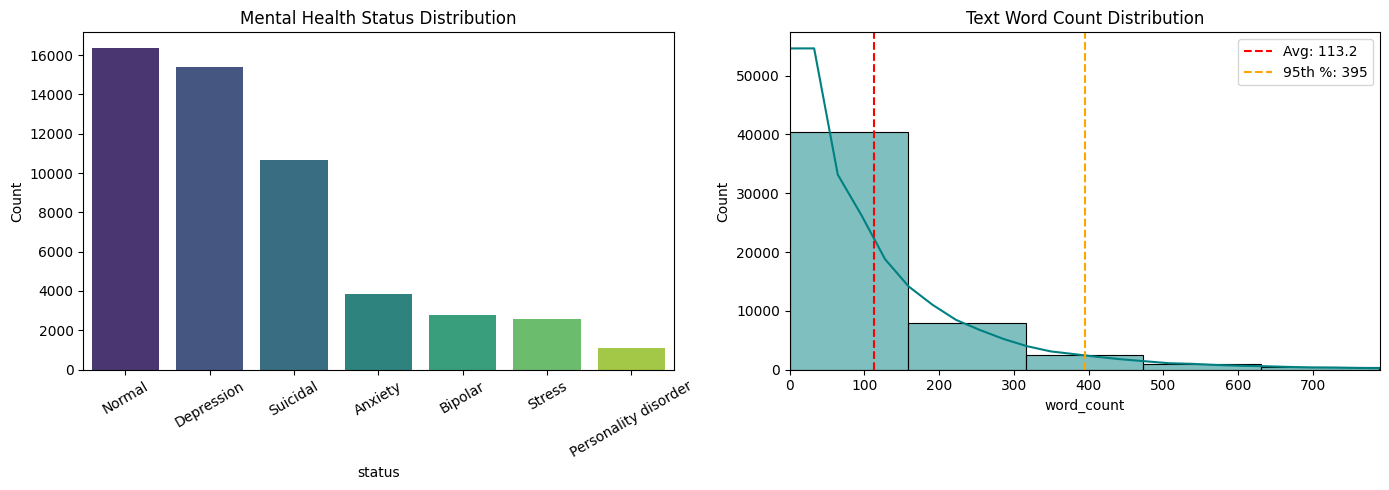

In [37]:
# =====================================================================
# TASK 1: DATASET UNDERSTANDING
# =====================================================================
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

print("--- Task 1: Downloading and Analyzing Dataset ---")

# 1. Download dataset directly from Kagglehub
path = kagglehub.dataset_download("suchintikasarkar/sentiment-analysis-for-mental-health")
print("Path to dataset files:", path)

# 2. Create the DataFrame
df = pd.read_csv(os.path.join(path, "Combined Data.csv"))

# Clean metadata columns and drop explicitly missing text or labels
if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis='columns')
df = df.dropna(subset=['statement', 'status']).reset_index(drop=True)

# 3. Analyze Number of Sentiment Classes & Class Imbalance
class_counts = df['status'].value_counts()
class_proportions = df['status'].value_counts(normalize=True) * 100

print(f"\nTotal Number of Sentiment Classes: {len(class_counts)}")
print("\nClass Distribution & Imbalance Analysis:")
for cls, count, prop in zip(class_counts.index, class_counts.values, class_proportions.values):
    print(f" - Class '{cls}': {count} samples ({prop:.2f}%)")

# 4. Analyze Text Distribution & Average Sentence Length
df['word_count'] = df['statement'].apply(lambda x: len(str(x).split()))
avg_len = df['word_count'].mean()
max_len = df['word_count'].max()
p95_len = int(df['word_count'].quantile(0.95)) # Cap at 95th percentile to eliminate outlier padding

print("\n" + "="*40)
print("Sentence Length Statistics:")
print(f" - Average Sentence Length: {avg_len:.2f} words")
print(f" - Maximum Sentence Length: {max_len} words")
print(f" - 95th Percentile Length (Recommended Max Len): {p95_len} words")
print("="*40 + "\n")

# 5. Visualizations
plt.figure(figsize=(14, 5))

# Plot Class Balance
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='status', order=class_counts.index, palette='viridis')
plt.title('Mental Health Status Distribution')
plt.xticks(rotation=30)
plt.ylabel('Count')

# Plot Sentence Length Distribution
plt.subplot(1, 2, 2)
sns.histplot(df['word_count'], kde=True, color='teal', bins=40)
plt.axvline(avg_len, color='red', linestyle='--', label=f'Avg: {avg_len:.1f}')
plt.axvline(p95_len, color='orange', linestyle='--', label=f'95th %: {p95_len}')
plt.title('Text Word Count Distribution')
plt.xlim(0, max(p95_len * 2, 100)) # Focus window on main density
plt.legend()

plt.tight_layout()
plt.show()

In [38]:
# =====================================================================
# TASK 2: TEXT PREPROCESSING
# =====================================================================
import nltk
import string
from nltk.corpus import stopwords

print("--- Task 2: Executing Text Preprocessing ---")

# Setup NLTK linguistic resources
nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('english'))

def text_preprocessing_pipeline(text):
    # a. Lowercase conversion
    text = str(text).lower()
    
    # b. Punctuation removal
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # c. Stopword removal
    words = text.split()
    cleaned_words = [word for word in words if word not in stop_words]
    
    return " ".join(cleaned_words)

# Apply cleaning to the dataset
df['cleaned_statement'] = df['statement'].apply(text_preprocessing_pipeline)

print("Sample Preprocessing Transformation:")
print("Original text: ", df['statement'].iloc[5])
print("Processed text:", df['cleaned_statement'].iloc[5])

--- Task 2: Executing Text Preprocessing ---
Sample Preprocessing Transformation:
Original text:  every break, you must be nervous, like something is wrong, but what the heck
Processed text: every break must nervous like something wrong heck


In [39]:
# =====================================================================
# TASK 3: SEQUENCE PREPARATION
# =====================================================================
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

print("--- Task 3: Tokenization & Padded Sequence Generation ---")

# Hyperparameters based on Task 1 analysis
MAX_VOCAB_SIZE = 15000  # Cut off vocabulary at top 15k words
MAX_SEQUENCE_LEN = p95_len  # Calculated dynamic 95th percentile from Task 1

# 1. Tokenizer & Vocabulary Generation
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(df['cleaned_statement'])

# 2. Convert text arrays into Numerical Sequences (Word Indexing)
sequences = tokenizer.texts_to_sequences(df['cleaned_statement'])

# 3. Padded Sequences
# NOTE: 'pre' padding is mathematically superior for Simple RNN units 
# to protect historical activation vectors from vanishing gradients.
X_data = pad_sequences(sequences, maxlen=MAX_SEQUENCE_LEN, padding='pre', truncating='post')

# 4. Target Label Engineering
label_encoder = LabelEncoder()
y_data = label_encoder.fit_transform(df['status'])
num_classes = len(label_encoder.classes_)

# 5. Stratified Train-Validation Split
X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.3, random_state=42, stratify=y_data
)

print(f"Final Input Matrix Shape: {X_data.shape}")
print(f"Total Unique Tokens Extracted: {len(tokenizer.word_index)}")
print(f"Vocabulary Size Limit Configured: {MAX_VOCAB_SIZE}")
print(f"Train/Validation Samples Split: {len(X_train)} / {len(X_test)}")

--- Task 3: Tokenization & Padded Sequence Generation ---
Final Input Matrix Shape: (52681, 395)
Total Unique Tokens Extracted: 81074
Vocabulary Size Limit Configured: 15000
Train/Validation Samples Split: 36876 / 15805


In [40]:
# =====================================================================
# TASK 4: BUILD SIMPLE RNN ARCHITECTURE
# =====================================================================
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

print("--- Task 4: Compiling Keras Simple RNN Architecture ---")

EMBEDDING_DIM = 64   # Latent feature depth for numeric word translation
RNN_UNITS = 64       # Hidden dimension sizes within recurrent loop

model = Sequential(name="Mental_Health_Sentiment_RNN")

# 1. Embedding Layer
model.add(Embedding(
    input_dim=MAX_VOCAB_SIZE, 
    output_dim=EMBEDDING_DIM, 
    input_length=MAX_SEQUENCE_LEN,
    name="Embedding_Layer"
))

# 2. SimpleRNN Layer
model.add(SimpleRNN(
    units=RNN_UNITS, 
    activation='tanh', 
    return_sequences=False, # Consolidates sequence steps into single vector
    name="Simple_RNN_Core"
))

# 3. Dense Output Layer
if num_classes == 2:
    model.add(Dense(units=1, activation='sigmoid', name="Output_Classification_Layer"))
    loss_fn = 'binary_crossentropy'
else:
    model.add(Dense(units=num_classes, activation='softmax', name="Output_Classification_Layer"))
    loss_fn = 'sparse_categorical_crossentropy'

# Output the layout summary
model.summary()

--- Task 4: Compiling Keras Simple RNN Architecture ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "Mental_Health_Sentiment_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Embedding_Layer (Embedding)     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Simple_RNN_Core (SimpleRNN)     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Classification_Layer     │ ?                      │   0 (unbuilt) │
│ (Dense)                         │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [41]:
# =====================================================================
# TASK 5: MODEL TRAINING & GPU OPTIMIZATION
# =====================================================================
from tensorflow.keras.optimizers import Adam

print("--- Task 5: Commencing GPU-Accelerated Training Loop ---")

# Verify GPU runtime presence inside Google Colab environment
gpu_device = tf.test.gpu_device_name()
if gpu_device:
    print(f"Success! Running on GPU Hardware Accelerator: {gpu_device}")
else:
    print("Warning: GPU not detected. Running training loops on basic CPU allocations.")

# Hyperparameters Tuning Configuration
LEARNING_RATE = 0.001   # Tuned learning rate step
BATCH_SIZE = 64         # Balance performance memory footprint 
EPOCHS = 5              # Balanced to evaluate fit cycles without overfitting

# Compile using tuned Adam optimizer values
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss=loss_fn,
    metrics=['accuracy']
)

# Fit the model using training data and validation matrices
history = model.fit(
    X_train, 
    y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

--- Task 5: Commencing GPU-Accelerated Training Loop ---
Success! Running on GPU Hardware Accelerator: /device:GPU:0
Epoch 1/5


577/577 ━━━━━━━━━━━━━━━━━━━━ 24s 36ms/step - accuracy: 0.5966 - loss: 1.0820 - val_accuracy: 0.6250 - val_loss: 0.9978
Epoch 2/5
577/577 ━━━━━━━━━━━━━━━━━━━━ 19s 33ms/step - accuracy: 0.7259 - loss: 0.7229 - val_accuracy: 0.6785 - val_loss: 0.8365
Epoch 3/5
577/577 ━━━━━━━━━━━━━━━━━━━━ 19s 33ms/step - accuracy: 0.8176 - loss: 0.5020 - val_accuracy: 0.6953 - val_loss: 0.8418
Epoch 4/5
577/577 ━━━━━━━━━━━━━━━━━━━━ 19s 33ms/step - accuracy: 0.8869 - loss: 0.3275 - val_accuracy: 0.6904 - val_loss: 0.9176
Epoch 5/5
577/577 ━━━━━━━━━━━━━━━━━━━━ 19s 33ms/step - accuracy: 0.9339 - loss: 0.2020 - val_accuracy: 0.6575 - val_loss: 1.1349


In [42]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\nFinal Evaluation on Validation Set: Loss = {loss:.4f}, Accuracy = {accuracy:.4f}")


Final Evaluation on Validation Set: Loss = 1.1349, Accuracy = 0.6575


--- Task 6: Generating Comprehensive Performance Metrics ---
494/494 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step

 SYSTEM PERFORMANCE METRICS (Weighted Evaluation):
 - Model Accuracy : 65.75%
 - Model Precision: 64.22% (Quality of positive alerts)
 - Model Recall   : 65.75% (Ability to detect at-risk flags)
 - Model F1-Score : 64.63% (Harmonic balance score)

### Detailed Classification Report ###
                      precision    recall  f1-score   support

             Anxiety       0.52      0.59      0.55      1152
             Bipolar       0.50      0.46      0.48       833
          Depression       0.62      0.65      0.63      4622
              Normal       0.83      0.93      0.88      4903
Personality disorder       0.39      0.28      0.33       323
              Stress       0.43      0.27      0.33       776
            Suicidal       0.55      0.45      0.49      3196

            accuracy                           0.66     15805
           macro avg       0.55      0.52      0.5

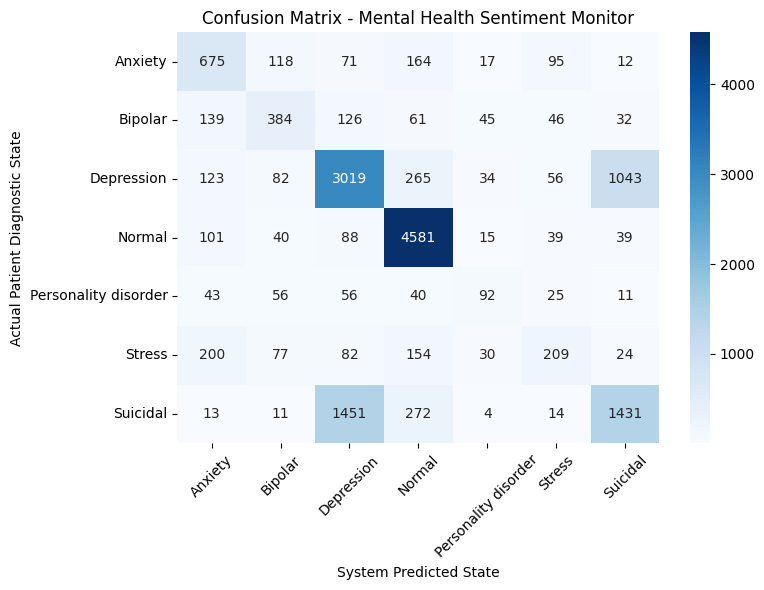

In [43]:
# =====================================================================
# TASK 6: MODEL EVALUATION
# =====================================================================
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report

print("--- Task 6: Generating Comprehensive Performance Metrics ---")

# 1. Generate predictions on the validation dataset
raw_predictions = model.predict(X_test, verbose=1)

# Check if model architecture is binary or multi-class to derive prediction indices
if num_classes == 2:
    y_pred = (raw_predictions > 0.5).astype("int32").flatten()
else:
    y_pred = np.argmax(raw_predictions, axis=1)

# 2. Compute Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)

# Calculate precision, recall, and f1-score (weighted handles class imbalance seamlessly)
precision, recall, f1_score, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')

print("\n" + "="*50)
print(f" SYSTEM PERFORMANCE METRICS (Weighted Evaluation):")
print(f" - Model Accuracy : {accuracy * 100:.2f}%")
print(f" - Model Precision: {precision * 100:.2f}% (Quality of positive alerts)")
print(f" - Model Recall   : {recall * 100:.2f}% (Ability to detect at-risk flags)")
print(f" - Model F1-Score : {f1_score * 100:.2f}% (Harmonic balance score)")
print("="*50 + "\n")

# 3. Print Detailed Classification Report per Class
target_names = [str(cls) for cls in label_encoder.classes_]
print("### Detailed Classification Report ###")
print(classification_report(y_test, y_pred, target_names=target_names))

# =====================================================================
# CONFUSION MATRIX VISUALIZATION
# =====================================================================
print("\n--- Generating Confusion Matrix Heatmap ---")
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=target_names, 
    yticklabels=target_names
)
plt.title('Confusion Matrix - Mental Health Sentiment Monitor')
plt.ylabel('Actual Patient Diagnostic State')
plt.xlabel('System Predicted State')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [44]:
# =====================================================================
# TASK 8: REAL-TIME PREDICTION SYSTEM
# =====================================================================
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

print("--- Task 8: Launching Real-Time Sentiment Monitor ---")

def monitor_user_input(custom_sentence):
    # 1. Subject the unseen sentence to the exact same Task 2 pipeline
    cleaned = text_preprocessing_pipeline(custom_sentence)
    
    # 2. Convert text to numerical indices using the fitted tokenizer
    sequence = tokenizer.texts_to_sequences([cleaned])
    
    # 3. Pad sequence to match the structural shape of training data
    padded = pad_sequences(sequence, maxlen=MAX_SEQUENCE_LEN, padding='pre')
    
    # 4. Generate prediction array probabilities
    prediction_probabilities = model.predict(padded, verbose=0)[0]
    
    # 5. Handle prediction lookup based on classification type
    if num_classes == 2:
        confidence = prediction_probabilities[0]
        class_idx = 1 if confidence > 0.5 else 0
        final_confidence = confidence if class_idx == 1 else 1 - confidence
    else:
        class_idx = np.argmax(prediction_probabilities)
        final_confidence = prediction_probabilities[class_idx]
        
    # Decode the numerical index back to its string emotional label
    predicted_sentiment = label_encoder.inverse_transform([class_idx])[0]
    
    # 6. Counselor Intervention Logic / Emotional Status Feedback
    print("\n" + "="*60)
    print(f"📥 Incoming Text : \"{custom_sentence}\"")
    print(f"🧠 Predicted Mood : {predicted_sentiment.upper()}")
    print(f"📊 Confidence Score: {final_confidence * 100:.2f}%")
    
    # Early Intervention Flag System
    if predicted_sentiment.lower() in ['depression', 'anxiety', 'suicidal', 'sadness', 'stressed']:
        print("🚨 FLAG: Negative sentiment trend detected. Counselor notification triggered.")
    else:
        print("✅ STATUS: Emotional well-being appears stable.")
    print("="*60)

# ==========================================
# TEST CASE ARRAYS (Unseen, Custom, and Emotional Text Examples)
# ==========================================

# 1. Custom Unseen Sentence (Baseline / Normal)
monitor_user_input("I spent the whole morning planning a new layout and I feel pretty productive.")

# 2. Emotional Example (High Anxiety / Stress Flag)
monitor_user_input("My exams are getting closer and my hands won't stop shaking. I feel completely overwhelmed and paralyzed.")

# 3. Emotional Example (Severe Risk / Depression Flag)
monitor_user_input("I feel so isolated and alone lately. It feels like waking up every day is just getting harder.")

--- Task 8: Launching Real-Time Sentiment Monitor ---

📥 Incoming Text : "I spent the whole morning planning a new layout and I feel pretty productive."
🧠 Predicted Mood : NORMAL
📊 Confidence Score: 97.56%
✅ STATUS: Emotional well-being appears stable.

📥 Incoming Text : "My exams are getting closer and my hands won't stop shaking. I feel completely overwhelmed and paralyzed."
🧠 Predicted Mood : STRESS
📊 Confidence Score: 83.99%
✅ STATUS: Emotional well-being appears stable.

📥 Incoming Text : "I feel so isolated and alone lately. It feels like waking up every day is just getting harder."
🧠 Predicted Mood : SUICIDAL
📊 Confidence Score: 72.05%
🚨 FLAG: Negative sentiment trend detected. Counselor notification triggered.
